In [1]:
# ============================================================
# Kaggle Notebook Script: PlantVillage Multi-class Classification
# Model: EfficientNet-B4 (PyTorch + Albumentations)
# ============================================================

import os
import random
import time
import warnings
import subprocess
import sys
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

# ---------------------------
# Install Albumentations if missing
# ---------------------------
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    print("Installing albumentations...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "albumentations"])
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

import cv2

In [2]:
# ---------------------------
# Configuration
# ---------------------------
@dataclass
class CFG:
    data_dir: str = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
    img_size: int = 380
    batch_size: int = 8  # small batch to reduce OOM risk
    num_workers: int = 2
    epochs: int = 15
    lr: float = 1e-4
    weight_decay: float = 1e-4
    train_split: float = 0.8
    seed: int = 42
    grad_clip: float = 1.0
    early_stopping_patience: int = 6
    focal_gamma: float = 2.0
    focal_alpha: float = 1.0
    checkpoint_path: str = "/kaggle/working/best_efficientnet_b4_plantvillage.pth"


cfg = CFG()


# ---------------------------
# Reproducibility
# ---------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic behavior (slightly slower)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(cfg.seed)

In [3]:
# ---------------------------
# Dataset Parsing
# ---------------------------
def build_dataframe(data_dir: str):
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Dataset directory not found: {data_dir}")

    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    if len(class_names) == 0:
        raise ValueError(f"No class folders found in: {data_dir}")

    records = []
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    for cls_name in class_names:
        cls_dir = os.path.join(data_dir, cls_name)
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            if os.path.isfile(fpath):
                records.append((fpath, class_to_idx[cls_name]))

    df = pd.DataFrame(records, columns=["path", "label"])
    if df.empty:
        raise ValueError("No image files found in dataset directory.")

    return df, class_names, class_to_idx


df, class_names, class_to_idx = build_dataframe(cfg.data_dir)
num_classes = len(class_names)
print(f"Total images: {len(df)}")
print(f"Num classes : {num_classes}")

Total images: 20639
Num classes : 15


In [4]:
# ---------------------------
# Stratified split (80/20)
# ---------------------------
train_df, val_df = train_test_split(
    df,
    test_size=(1.0 - cfg.train_split),
    random_state=cfg.seed,
    stratify=df["label"],
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Val samples  : {len(val_df)}")


# ---------------------------
# Albumentations Transforms
# ---------------------------
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_tfms = A.Compose([
    A.RandomResizedCrop(
    size=(cfg.img_size, cfg.img_size),
    scale=(0.75, 1.0),
    ratio=(0.9, 1.1),
    p=1.0
),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.6),
    A.Normalize(mean=imagenet_mean, std=imagenet_std),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(height=cfg.img_size, width=cfg.img_size),
    A.Normalize(mean=imagenet_mean, std=imagenet_std),
    ToTensorV2(),
])

Train samples: 16511
Val samples  : 4128


In [5]:
valid_paths = []

for path in train_df["path"]:
    if cv2.imread(path) is not None:
        valid_paths.append(path)

train_df = train_df[train_df["path"].isin(valid_paths)].reset_index(drop=True)

In [6]:
# ---------------------------
# Dataset / Dataloader
# ---------------------------
class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label = int(self.df.loc[idx, "label"])

        image = cv2.imread(img_path)

        # 🔥 Handle corrupted images safely
        if image is None:
            print(f"⚠️ Skipping corrupted image: {img_path}")
            # pick another random sample instead of crashing
            new_idx = np.random.randint(0, len(self.df))
            return self.__getitem__(new_idx)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transforms is not None:
            image = self.transforms(image=image)["image"]

        return image, label


train_ds = PlantDiseaseDataset(train_df, transforms=train_tfms)
val_ds = PlantDiseaseDataset(val_df, transforms=val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
)

In [7]:
train_df = train_df[train_df["path"].str.endswith((".jpg", ".jpeg", ".png"))]
val_df = val_df[val_df["path"].str.endswith((".jpg", ".jpeg", ".png"))]

In [8]:
# ---------------------------
# Model
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Equivalent to pretrained=True in newer torchvision API
weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1
model = models.efficientnet_b4(weights=weights)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)

# Full fine-tuning enabled (all params trainable by default)
for p in model.parameters():
    p.requires_grad = True

model = model.to(device)

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:02<00:00, 31.2MB/s]


In [9]:
# ---------------------------
# Multi-class Focal Loss (manual)
# ---------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)  # per-sample CE
        pt = torch.exp(-ce_loss)            # pt = softmax prob of true class
        focal = self.alpha * ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal


criterion = FocalLoss(alpha=cfg.focal_alpha, gamma=cfg.focal_gamma)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

In [10]:
# ---------------------------
# Train / Validate Functions
# ---------------------------
def run_train_epoch(model, loader, optimizer, criterion, scaler, device, grad_clip):

    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    pbar = tqdm(loader, total=len(loader))

    for images, targets in pbar:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

        pbar.set_postfix(loss=loss.item())

    acc = accuracy_score(all_targets, all_preds)
    return total_loss / len(loader), acc
    

@torch.no_grad()
def run_val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in tqdm(loader, desc="Validating", leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, targets)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        targs = targets.detach().cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(targs)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

In [11]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([8, 3, 380, 380]) torch.Size([8])


In [12]:
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

In [13]:
torch.save(model.state_dict(), "/kaggle/working/test_save.pth")
print("Test save complete")

Test save complete


In [14]:
best_f1 = -1.0
patience_counter = 0

print("\n🚀 Starting Training...\n")

for epoch in range(1, cfg.epochs + 1):

    print(f"\n========== Epoch {epoch}/{cfg.epochs} ==========")
    start_time = time.time()

    # ---- TRAIN ----
    train_loss, train_acc = run_train_epoch(
        model, train_loader, optimizer, criterion, scaler, device, cfg.grad_clip
    )

    # ---- VALIDATE ----
    val_loss, val_acc, val_f1, val_prec, val_rec = run_val_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - start_time

    print(f"\n📊 Epoch Summary:")
    print(f"LR         : {current_lr:.6f}")
    print(f"Train      : Loss {train_loss:.4f} | Acc {train_acc:.4f}")
    print(f"Validation : Loss {val_loss:.4f} | Acc {val_acc:.4f}")
    print(f"F1 {val_f1:.4f} | Precision {val_prec:.4f} | Recall {val_rec:.4f}")
    print(f"Time       : {elapsed:.1f}s")

    # ---- SAVE BEST ----
    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0

        torch.save(model.state_dict(), cfg.checkpoint_path)

        print(f"\n💾 Model saved to: {cfg.checkpoint_path}")
        print(f"Current best F1: {best_f1:.4f}")

        # verify file exists
        print("File exists?", os.path.exists(cfg.checkpoint_path))

    else:
        patience_counter += 1
        print(f"\n⏳ No improvement ({patience_counter}/{cfg.early_stopping_patience})")

    if patience_counter >= cfg.early_stopping_patience:
        print("\n🛑 Early stopping triggered.")
        break

print("\n🎉 Training Finished!")


🚀 Starting Training...


========== Epoch 1/15 ==========


Validating:  34%|███▍      | 176/516 [00:58<01:18,  4.33it/s]

⚠️ Skipping corrupted image: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c



📊 Epoch Summary:
LR         : 0.000099
Train      : Loss 0.9620 | Acc 0.5909
Validation : Loss 0.1486 | Acc 0.9036
F1 0.8838 | Precision 0.9055 | Recall 0.8760
Time       : 699.6s

💾 Model saved to: /kaggle/working/best_efficientnet_b4_plantvillage.pth
Current best F1: 0.8838
File exists? True

========== Epoch 2/15 ==========


Validating:  34%|███▍      | 178/516 [00:12<00:23, 14.13it/s]

...

⚠️ Skipping corrupted image: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c



📊 Epoch Summary:
LR         : 0.000001
Train      : Loss 0.0472 | Acc 0.9808
Validation : Loss 0.0173 | Acc 0.9949
F1 0.9935 | Precision 0.9925 | Recall 0.9946
Time       : 517.4s

⏳ No improvement (3/6)

========== Epoch 15/15 ==========


Validating:  34%|███▍      | 176/516 [00:12<00:24, 13.85it/s]

⚠️ Skipping corrupted image: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c



📊 Epoch Summary:
LR         : 0.000000
Train      : Loss 0.0527 | Acc 0.9789
Validation : Loss 0.0171 | Acc 0.9944
F1 0.9942 | Precision 0.9940 | Recall 0.9943
Time       : 510.2s

⏳ No improvement (4/6)

🎉 Training Finished!


In [15]:
print("\nLoading best model for final evaluation...")

model.load_state_dict(torch.load(cfg.checkpoint_path, map_location=device))
model.to(device)

val_loss, val_acc, val_f1, val_prec, val_rec = run_val_epoch(
    model, val_loader, criterion, device
)

print("\n================ Final Validation Metrics ================")
print(f"Accuracy       : {val_acc:.4f}")
print(f"Macro F1       : {val_f1:.4f}")
print(f"Macro Precision: {val_prec:.4f}")
print(f"Macro Recall   : {val_rec:.4f}")
print("==========================================================\n")

print(f"Best checkpoint loaded from: {cfg.checkpoint_path}")


Loading best model for final evaluation...


Validating:  34%|███▍      | 177/516 [00:12<00:24, 13.61it/s]

⚠️ Skipping corrupted image: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c



================ Final Validation Metrics ================
Accuracy       : 0.9961
Macro F1       : 0.9961
Macro Precision: 0.9966
Macro Recall   : 0.9956

Best checkpoint loaded from: /kaggle/working/best_efficientnet_b4_plantvillage.pth


Loading best model...


Evaluating:  34%|███▍      | 177/516 [00:12<00:24, 14.03it/s]

⚠️ Skipping corrupted image: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c


Evaluating: 100%|██████████| 516/516 [00:37<00:00, 13.67it/s]


Total val samples evaluated: 4128
Prob matrix shape          : (4128, 15)


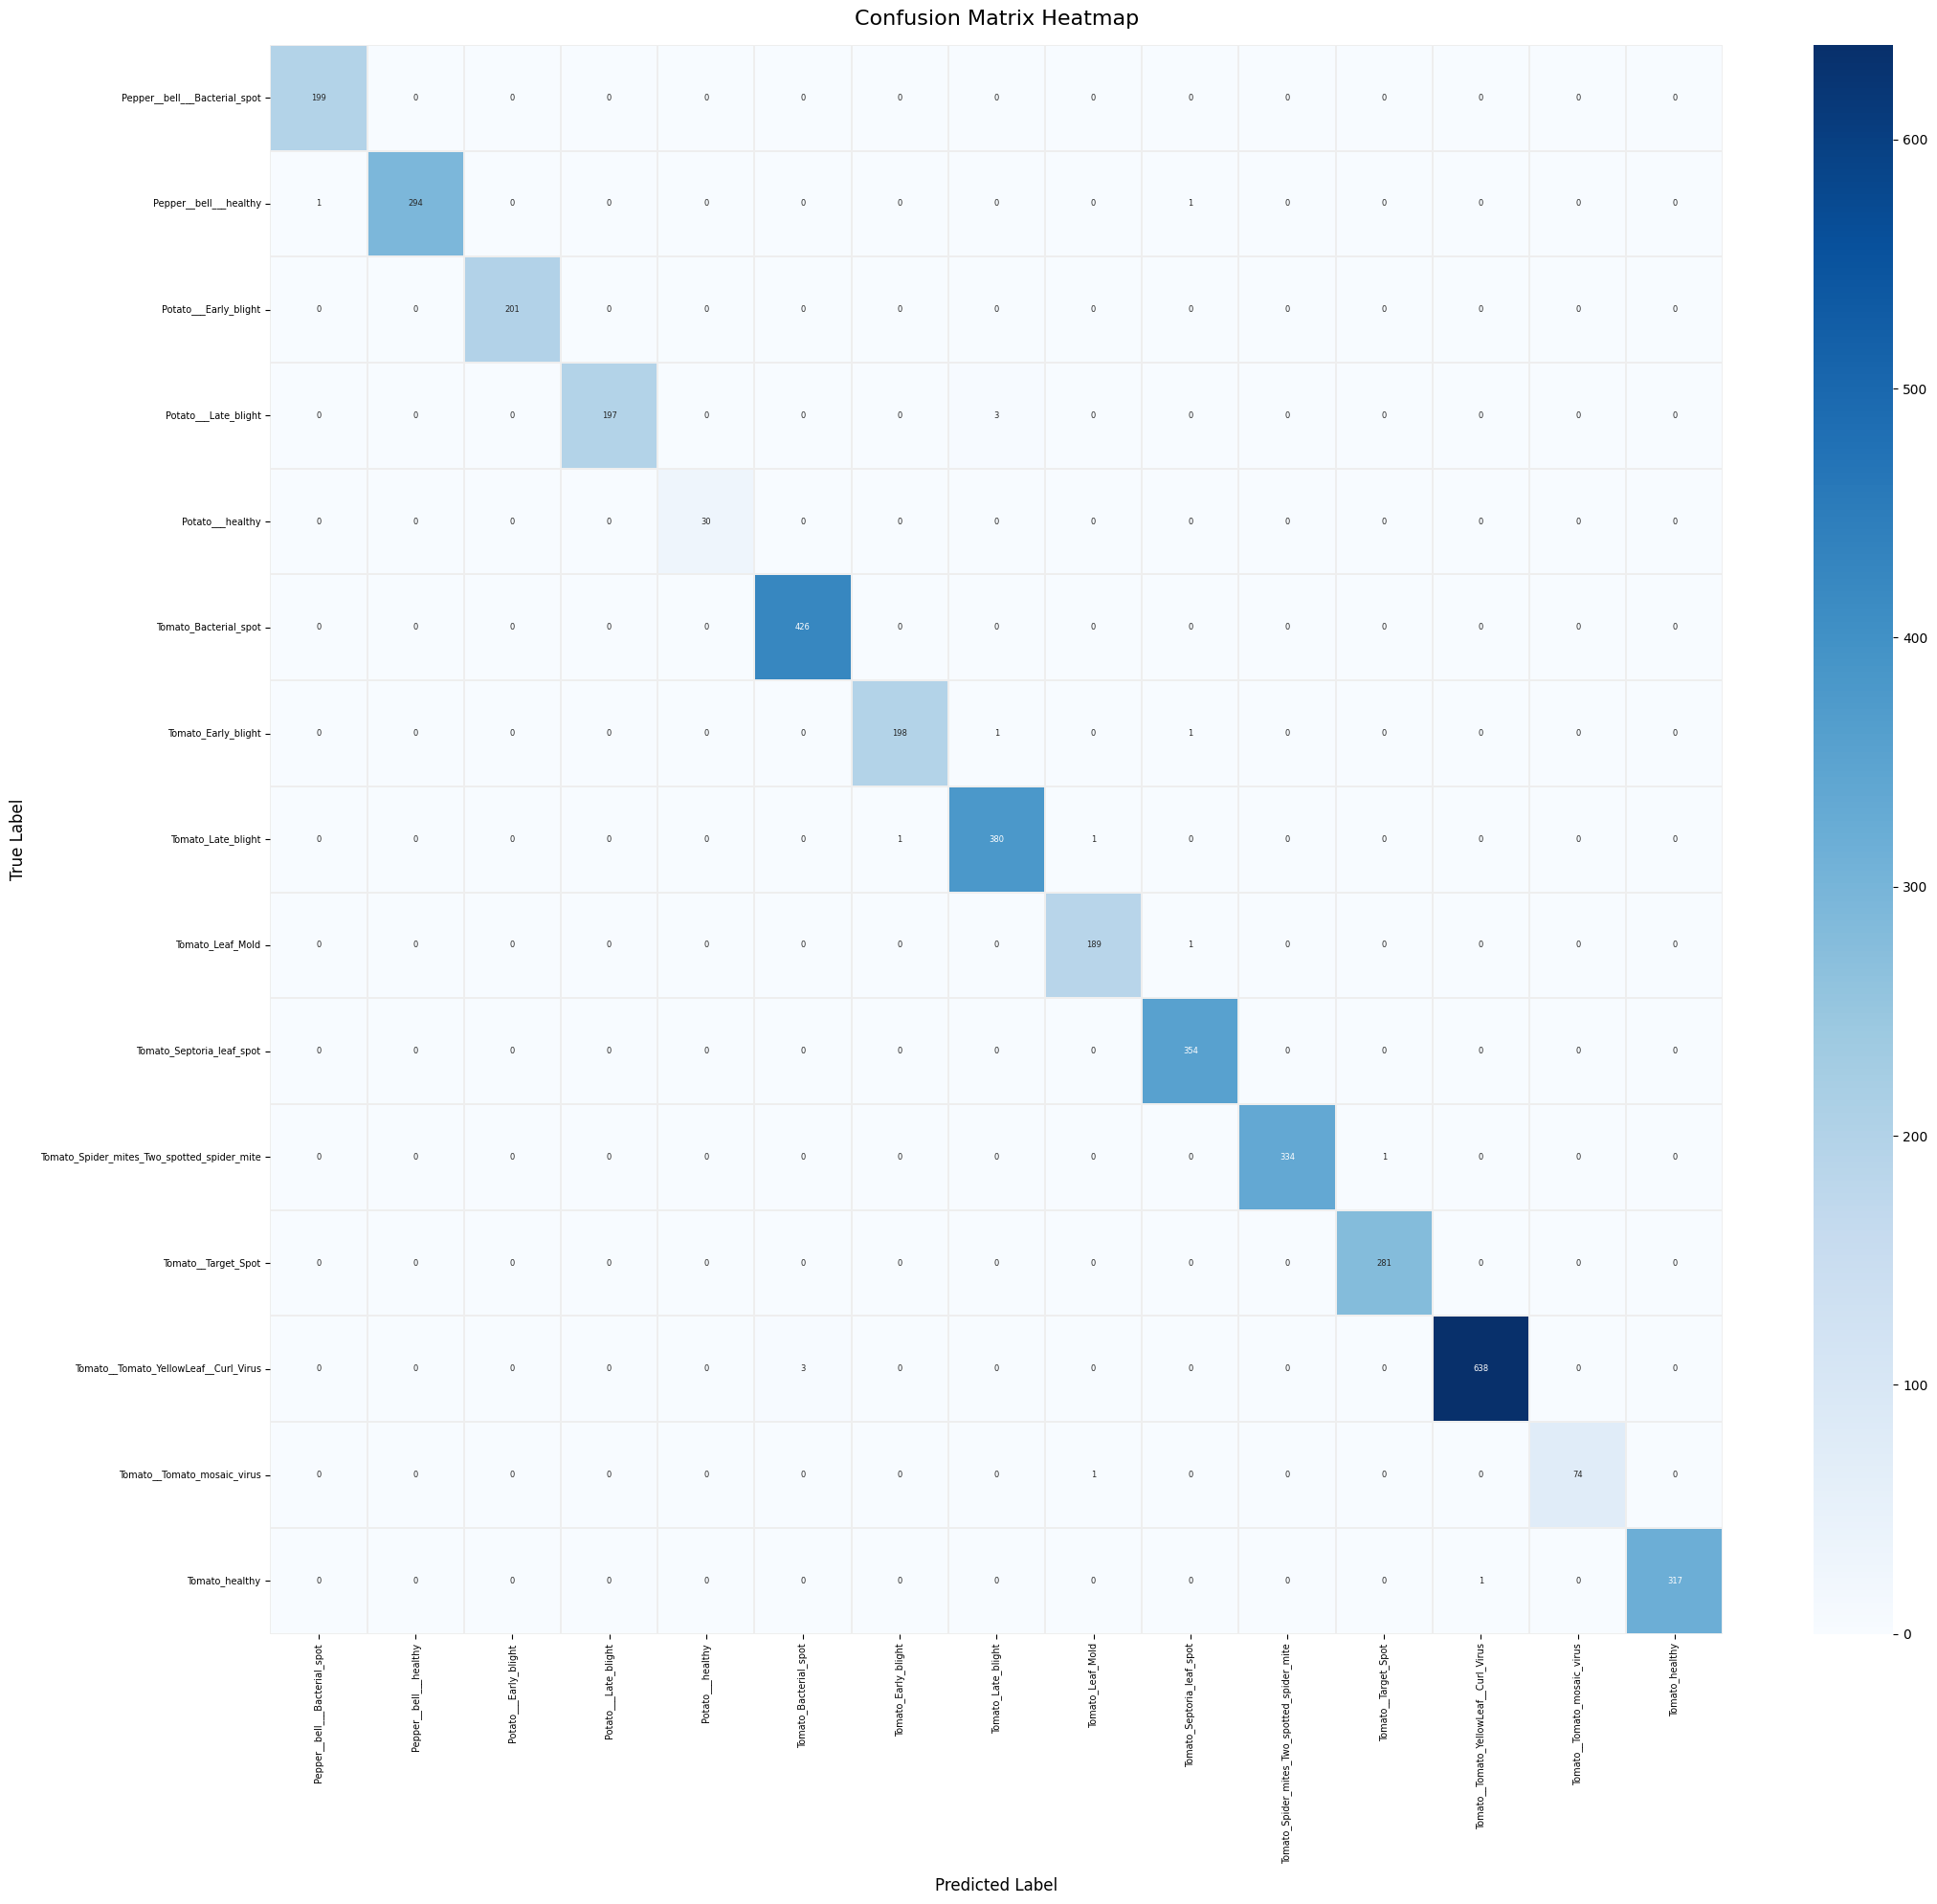

✅ Saved → fig7_confusion_matrix.png


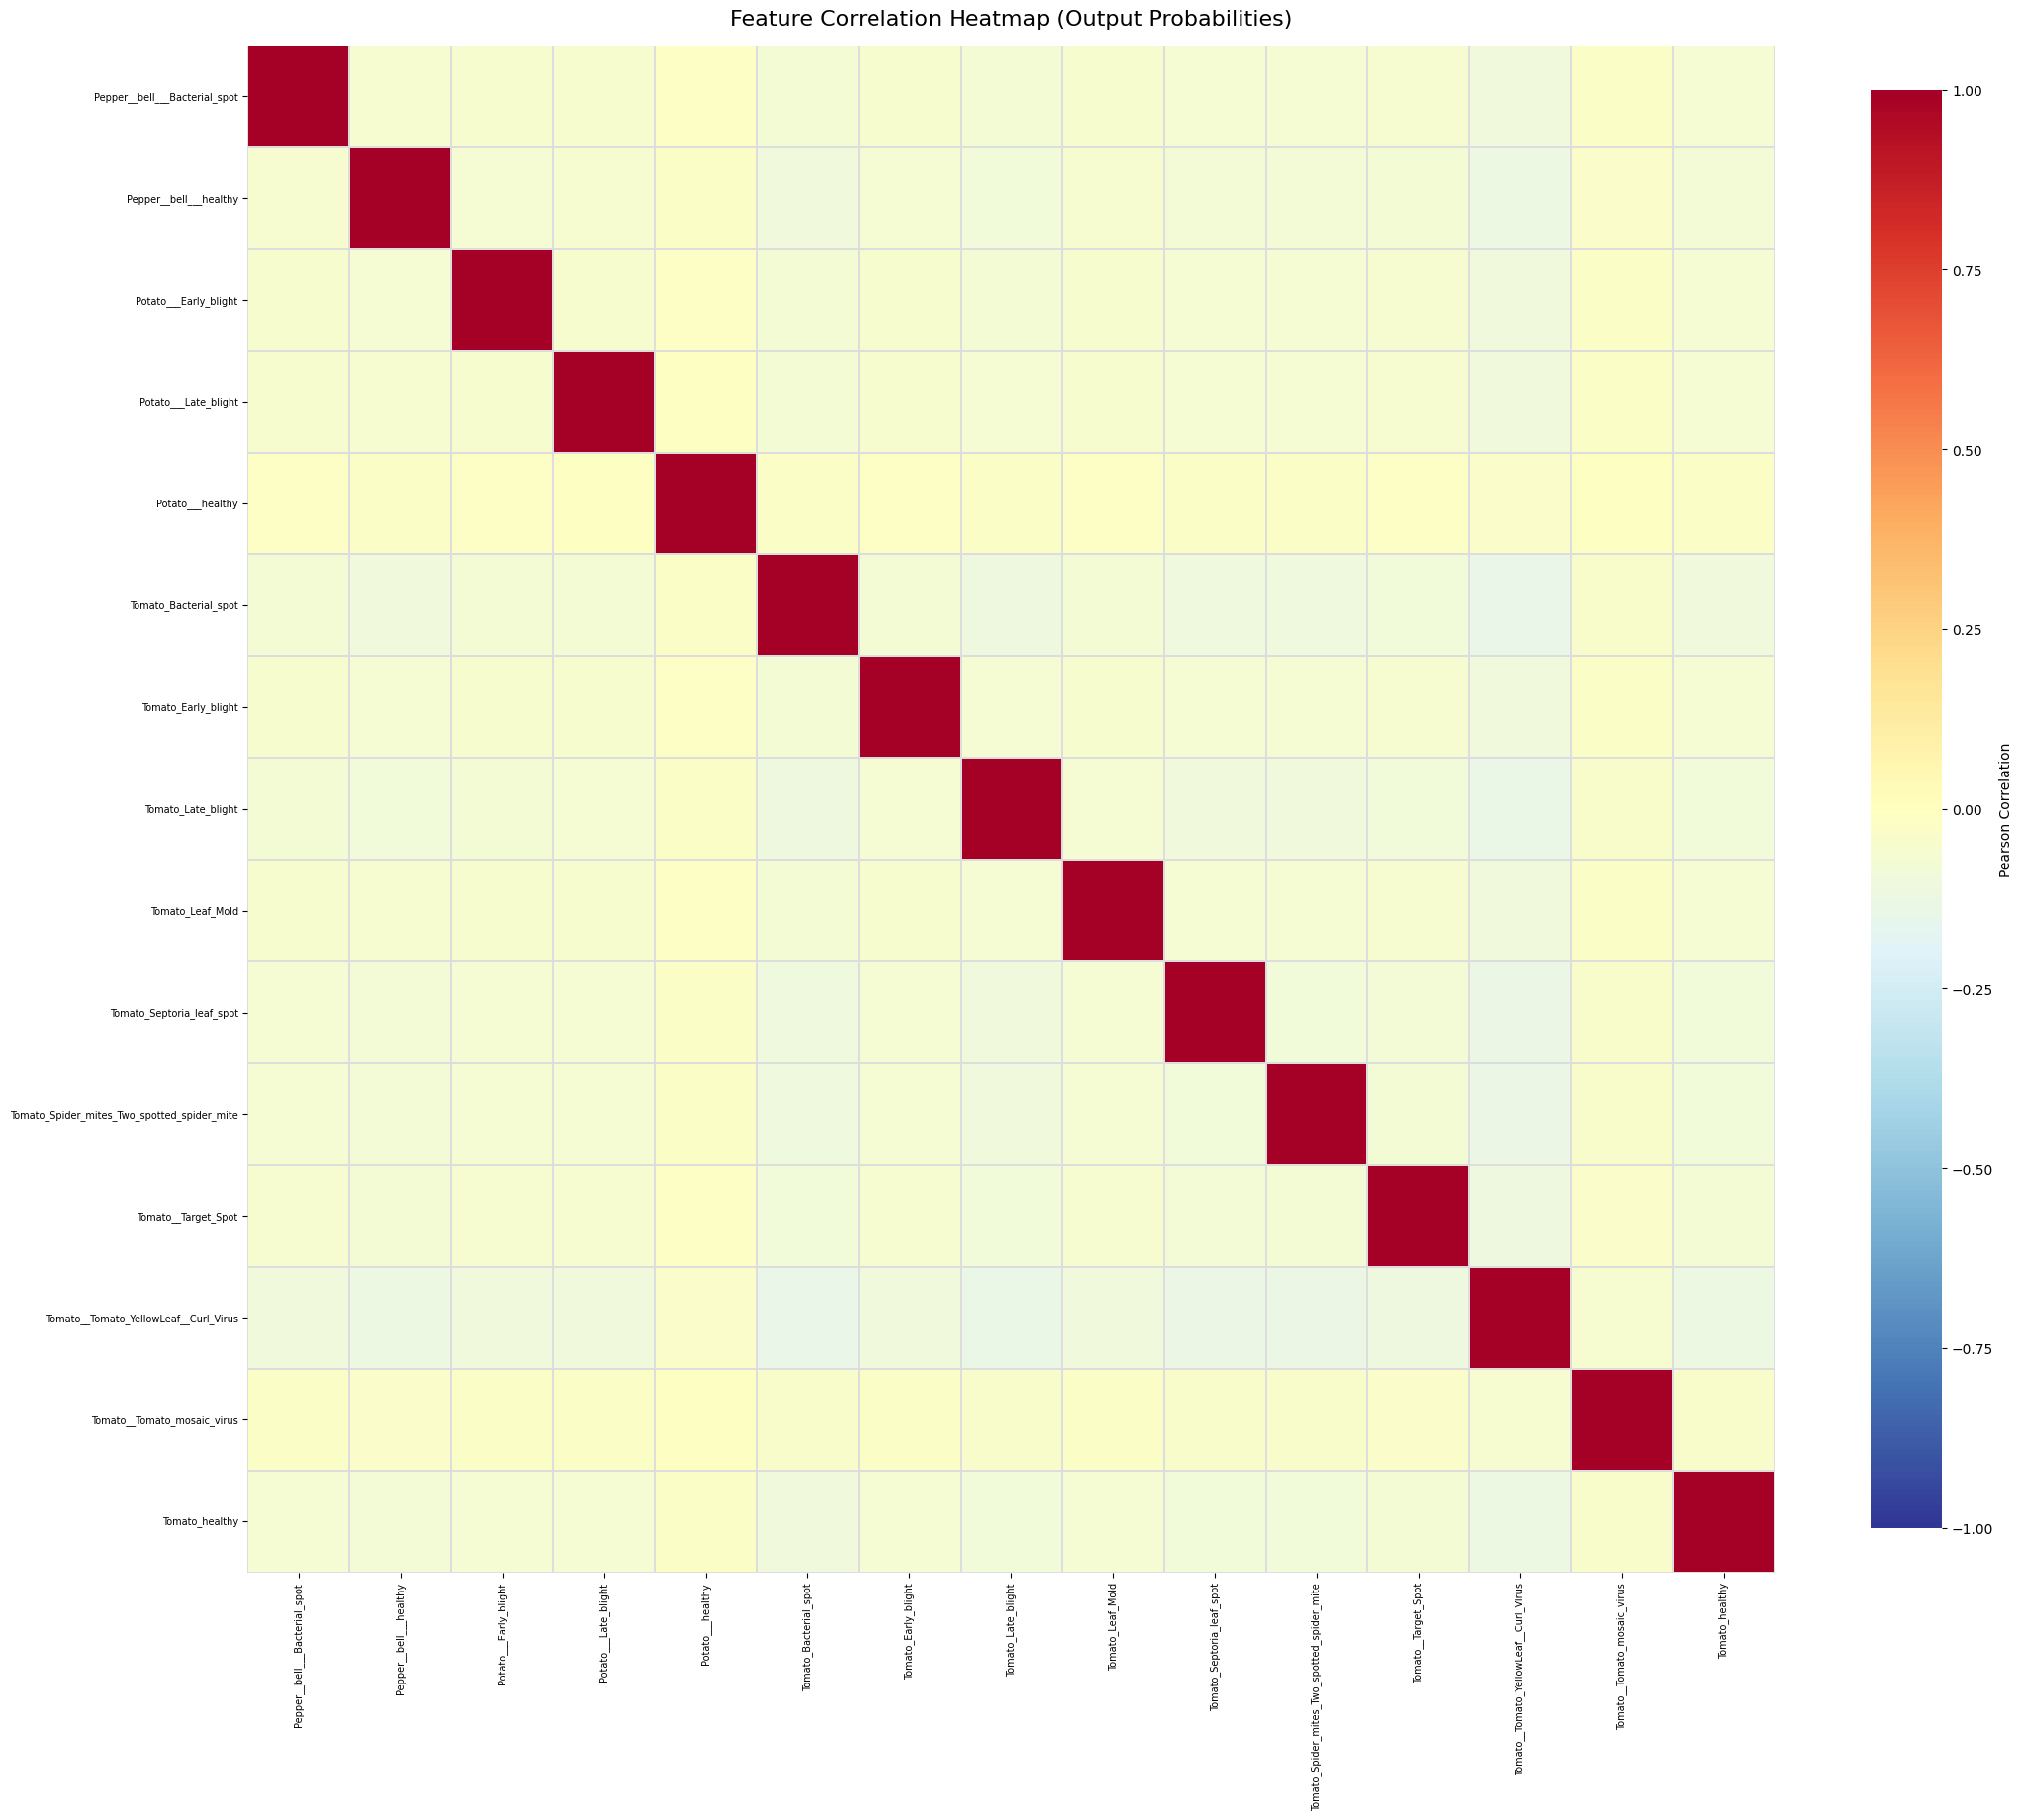

✅ Saved → fig8_correlation_heatmap.png

====== Final Metrics for Paper (Table II) ======
Validation Accuracy  : 0.9961  (99.61%)
Macro F1-Score       : 0.9961
Macro Precision      : 0.9966
Macro Recall         : 0.9956

Files saved to /kaggle/working/:
  → fig7_confusion_matrix.png
  → fig8_correlation_heatmap.png


In [16]:
# ============================================================
# CONFUSION MATRIX + CORRELATION HEATMAP
# Paste this as a NEW cell after training is done
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

# ── STEP 1: Load best model ────────────────────────────────
print("Loading best model...")
model.load_state_dict(torch.load(cfg.checkpoint_path, map_location=device))
model.eval()
model.to(device)

# ── STEP 2: Get all predictions + probabilities ────────────
all_preds    = []
all_targets  = []
all_probs    = []  # for correlation heatmap

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)   # (B, num_classes)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs   = np.vstack(all_probs)   # (N, num_classes)

print(f"Total val samples evaluated: {len(all_preds)}")
print(f"Prob matrix shape          : {all_probs.shape}")


# ============================================================
# FIG 7 — CONFUSION MATRIX HEATMAP
# ============================================================
cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3,
    linecolor='#eeeeee',
    annot_kws={"size": 6},
    ax=ax
)
ax.set_title('Confusion Matrix Heatmap', fontsize=16, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label',      fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=90,  labelsize=7)
ax.tick_params(axis='y', rotation=0,   labelsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/fig7_confusion_matrix.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved → fig7_confusion_matrix.png")


# ============================================================
# FIG 8 — CORRELATION HEATMAP OF OUTPUT PROBABILITIES
# ============================================================

# Pearson correlation between each pair of class probability vectors
# all_probs shape: (N, num_classes) — correlate columns
prob_df     = pd.DataFrame(all_probs, columns=class_names)
corr_matrix = prob_df.corr(method='pearson')   # (num_classes, num_classes)

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(
    corr_matrix,
    annot=False,          # too many classes for annotation
    cmap='RdYlBu_r',
    vmin=-1.0,
    vmax=1.0,
    center=0,
    square=True,
    linewidths=0.1,
    linecolor='#dddddd',
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (Output Probabilities)',
             fontsize=16, pad=15)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/fig8_correlation_heatmap.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved → fig8_correlation_heatmap.png")


# ============================================================
# PRINT FINAL METRICS SUMMARY
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

acc  = accuracy_score(all_targets, all_preds)
f1   = f1_score(all_targets, all_preds, average='macro', zero_division=0)
prec = precision_score(all_targets, all_preds, average='macro', zero_division=0)
rec  = recall_score(all_targets, all_preds, average='macro', zero_division=0)

print("\n====== Final Metrics for Paper (Table II) ======")
print(f"Validation Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro F1-Score       : {f1:.4f}")
print(f"Macro Precision      : {prec:.4f}")
print(f"Macro Recall         : {rec:.4f}")
print("================================================")
print("\nFiles saved to /kaggle/working/:")
print("  → fig7_confusion_matrix.png")
print("  → fig8_correlation_heatmap.png")

In [17]:
!pip install torchinfo

In [18]:
import torch
import torch.nn as nn
from torchvision import models
from torchinfo import summary

In [19]:
model = models.efficientnet_b4(weights=None)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 15)   # change if your classes differ
)

In [20]:
model_path = "/kaggle/input/datasets/gorthinandini/best-model/best_efficientnet_b4_plantvillage (7).pth"

model.load_state_dict(torch.load(model_path, map_location="cpu"))

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [21]:
summary(model, input_size=(1,3,380,380))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 15]                   --
├─Sequential: 1-1                                       [1, 1792, 12, 12]         --
│    └─Conv2dNormActivation: 2-1                        [1, 48, 190, 190]         --
│    │    └─Conv2d: 3-1                                 [1, 48, 190, 190]         1,296
│    │    └─BatchNorm2d: 3-2                            [1, 48, 190, 190]         96
│    │    └─SiLU: 3-3                                   [1, 48, 190, 190]         --
│    └─Sequential: 2-2                                  [1, 24, 190, 190]         --
│    │    └─MBConv: 3-4                                 [1, 24, 190, 190]         2,940
│    │    └─MBConv: 3-5                                 [1, 24, 190, 190]         1,206
│    └─Sequential: 2-3                                  [1, 32, 95, 95]           --
│    │    └─MBConv: 3-6                            

In [22]:
!pip install torchinfo rich

In [23]:
from rich.console import Console
from rich.table import Table
from torchinfo import summary

console = Console()

model_summary = summary(model, input_size=(1,3,380,380), verbose=0)

table = Table(title="EfficientNet-B4 Model Summary")

table.add_column("Layer Type", style="cyan")
table.add_column("Output Shape", style="green")
table.add_column("Param #", style="magenta")

important_layers = ["Conv2d", "BatchNorm2d", "AdaptiveAvgPool2d", "Dropout", "Linear"]

layers = [l for l in model_summary.summary_list if l.class_name in important_layers]

step = max(1, len(layers) // 10)

for layer in layers[::step][:10]:
    table.add_row(
        layer.class_name,
        str(layer.output_size),
        str(layer.num_params)
    )

console.print(table)

# ---- Parameter Summary ----
total_params = model_summary.total_params
trainable_params = model_summary.trainable_params
non_trainable_params = total_params - trainable_params

console.print()
console.print(f"[bold]Total params:[/bold] [green]{total_params:,}[/green]")
console.print(f"[bold]Trainable params:[/bold] [green]{trainable_params:,}[/green]")
console.print(f"[bold]Non-trainable params:[/bold] [green]{non_trainable_params:,}[/green]")

           EfficientNet-B4 Model Summary           
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer Type        ┃ Output Shape      ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Conv2d            │ [1, 48, 190, 190] │ 1296    │
│ AdaptiveAvgPool2d │ [1, 192, 1, 1]    │ 0       │
│ Conv2d            │ [1, 192, 1, 1]    │ 1728    │
│ BatchNorm2d       │ [1, 56, 48, 48]   │ 112     │
│ BatchNorm2d       │ [1, 672, 24, 24]  │ 1344    │
│ BatchNorm2d       │ [1, 672, 24, 24]  │ 1344    │
│ Conv2d            │ [1, 40, 1, 1]     │ 38440   │
│ Conv2d            │ [1, 272, 12, 12]  │ 261120  │
│ Conv2d            │ [1, 1632, 12, 12] │ 443904  │
│ Conv2d            │ [1, 1632, 12, 12] │ 40800   │
└───────────────────┴───────────────────┴─────────┘

Total params: 17,575,511

Trainable params: 17,575,511

Non-trainable params: 0

NameError: name 'train_acc_list' is not defined

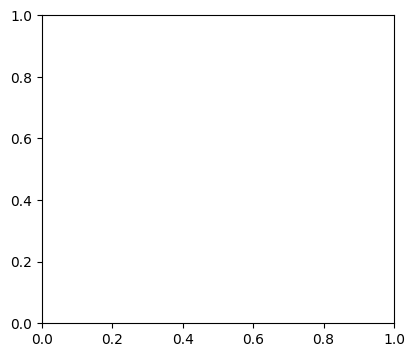

In [24]:
import matplotlib.pyplot as plt

# number of epochs
epochs = range(1, 26)

plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, train_acc_list, label="Train Accuracy")
plt.plot(epochs, val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, train_loss_list, label="Train Loss")
plt.plot(epochs, val_loss_list, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Focal Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save for research paper
plt.savefig("training_validation_curves.png", dpi=600)

plt.show()